In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
file_path = r"C:\Users\singh\Downloads\561 file for ML Model.xlsx"

df = pd.read_excel(file_path)

print("\n========== DATASET INFORMATION ==========")
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns.tolist())


========== DATASET INFORMATION ==========
Dataset Shape : (560, 30)

Columns:
['C', 'Mn', 'Si', 'Al', 'B', 'N', 'Ca', 'P', 'Ni', 'S', 'Cr', 'Mo', 'Ti', 'V', 'Nb', 'Ni.1', 'Zn', 'Cu', 'Sn', 'W', 'Co', 'Zr', 'O', 'Mg', 'Ti*', 'UTS (MPa)', 'YS (MPa)', 'Total Elongation (%)', 'Engg. Strain', 'n-Value']


In [3]:
target_columns = df.columns.tolist()

X = df.copy()
y = df.copy()

print("Original Dataset Shape :", df.shape)
print("Input Shape :", X.shape)
print("Output Shape :", y.shape)

print("\nTotal Target Columns :", len(target_columns))
print("\nTarget Columns :")

for column in target_columns:
    print(column)


Original Dataset Shape : (560, 30)
Input Shape : (560, 30)
Output Shape : (560, 30)

Total Target Columns : 30

Target Columns :
C
Mn
Si
Al
B
N
Ca
P
Ni
S
Cr
Mo
Ti
V
Nb
Ni.1
Zn
Cu
Sn
W
Co
Zr
O
Mg
Ti*
UTS (MPa)
YS (MPa)
Total Elongation (%)
Engg. Strain
n-Value


In [4]:
print("\n========== MISSING VALUES ==========")

print("Input Missing Values :", X.isnull().sum().sum())
print("Output Missing Values :", y.isnull().sum().sum())


========== MISSING VALUES ==========
Input Missing Values : 0
Output Missing Values : 0


In [5]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n========== DATA SPLIT ==========")

print("Training Samples :", X_train.shape[0])
print("Validation Samples :", X_validation.shape[0])


========== DATA SPLIT ==========
Training Samples : 448
Validation Samples : 112


In [6]:
X_scaler = StandardScaler()
y_scaler = StandardScaler()


X_train_scaled = X_scaler.fit_transform(X_train)

X_validation_scaled = X_scaler.transform(
    X_validation
)


y_train_scaled = y_scaler.fit_transform(
    y_train
)


In [7]:
svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1,
    gamma="scale"
)


# MultiOutputRegressor is required
# because we have 3 output variables

model = MultiOutputRegressor(
    svr_model
)
print("\n========== TRAINING SVR MODEL ==========")

model.fit(
    X_train_scaled,
    y_train_scaled
)

print("SVR Model Training Completed")


========== TRAINING SVR MODEL ==========
SVR Model Training Completed


In [8]:
y_pred_scaled = model.predict(
    X_validation_scaled
)


# Convert prediction back to original scale

y_pred = y_scaler.inverse_transform(
    y_pred_scaled
)

In [9]:
mse = mean_squared_error(
    y_validation,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_validation,
    y_pred
)

r2 = r2_score(
    y_validation,
    y_pred
)


print("\n========== SVR MODEL RESULT ==========")

print("MSE      :", mse)

print("RMSE     :", rmse)

print("MAE      :", mae)

print("R2 Score :", r2)


========== SVR MODEL RESULT ==========
MSE      : 217.5100204830908
RMSE     : 14.748220926033445
MAE      : 1.9835582659033513
R2 Score : -7.225865997305385


In [10]:
y_pred = np.asarray(y_pred)

y_validation_array = y_validation.to_numpy()


for i, column in enumerate(target_columns):

    score = r2_score(
        y_validation_array[:, i],
        y_pred[:, i]
    )

    print(
        column,
        ":",
        score
    )


C : 0.8687888336414531
Mn : 0.9302839480357286
Si : 0.9421999809419447
Al : 0.96386766611024
B : 0.8890757977273123
N : 0.9554049785119025
Ca : 0.97820032681704
P : 0.9592549841240845
Ni : 0.9812237004716259
S : 0.9360795767848034
Cr : 0.9014746234864469
Mo : 0.8687335390290949
Ti : 0.9639172313961385
V : 0.9058692929117591
Nb : 0.9704122298754881
Ni.1 : 0.9409128546621244
Zn : 0.0
Cu : 0.968447740531765
Sn : 0.0
W : 0.7036152142357007
Co : 0.57675967570077
Zr : 0.593927232340957
O : -240.95268240311026
Mg : 0.8368753013567721
Ti* : 0.8777420396348032
UTS (MPa) : 0.92738023833959
YS (MPa) : 0.9205050919705449
Total Elongation (%) : 0.9388153578621008
Engg. Strain : 0.9388153578621008
n-Value : 0.9381196695864265


In [11]:
print("\n========== SUPPORT VECTOR INFORMATION ==========")


for i, estimator in enumerate(model.estimators_):

    support_vector_count = len(
        estimator.support_
    )

    print(
        target_columns[i],
        "Support Vectors :",
        support_vector_count
    )


========== SUPPORT VECTOR INFORMATION ==========
C Support Vectors : 146
Mn Support Vectors : 152
Si Support Vectors : 172
Al Support Vectors : 141
B Support Vectors : 139
N Support Vectors : 144
Ca Support Vectors : 118
P Support Vectors : 161
Ni Support Vectors : 104
S Support Vectors : 171
Cr Support Vectors : 147
Mo Support Vectors : 175
Ti Support Vectors : 157
V Support Vectors : 132
Nb Support Vectors : 151
Ni.1 Support Vectors : 143
Zn Support Vectors : 113
Cu Support Vectors : 129
Sn Support Vectors : 113
W Support Vectors : 112
Co Support Vectors : 111
Zr Support Vectors : 105
O Support Vectors : 98
Mg Support Vectors : 112
Ti* Support Vectors : 120
UTS (MPa) Support Vectors : 143
YS (MPa) Support Vectors : 163
Total Elongation (%) Support Vectors : 141
Engg. Strain Support Vectors : 141
n-Value Support Vectors : 141


In [12]:
prediction_df = pd.DataFrame()


for i, column in enumerate(target_columns):

    prediction_df[
        "Actual_" + column
    ] = y_validation.iloc[:, i].values

    prediction_df[
        "Predicted_" + column
    ] = y_pred[:, i]


print("\n========== PREDICTION RESULT ==========")

print(
    prediction_df.head(10)
)


========== PREDICTION RESULT ==========
   Actual_C  Predicted_C  Actual_Mn  Predicted_Mn  Actual_Si  Predicted_Si  \
0     0.041     0.045589      0.273      0.286973      0.022      0.027531   
1     0.150     0.147129      1.100      1.155150      0.200      0.203003   
2     0.038     0.037824      2.560      2.596168      0.730      0.729760   
3     0.052     0.084803      1.510      1.711852      0.020      0.131847   
4     0.040     0.047277      1.600      1.548860      0.100      0.115146   
5     0.100     0.095407      1.600      1.775699      0.010      0.114610   
6     0.090     0.104708      1.140      1.528136      2.140      1.707648   
7     0.100     0.099387      2.500      2.513013      0.600      0.586561   
8     0.071     0.070606      2.498      2.470361      0.275      0.282574   
9     0.095     0.109253      1.650      1.708166      0.300      0.348873   

   Actual_Al  Predicted_Al  Actual_B  Predicted_B  ...  Actual_UTS (MPa)  \
0      0.035      0.0568

In [13]:
epsilon = 0.1


for i, column in enumerate(target_columns):
    actual = y_validation.iloc[:, i].values
    predicted = y_pred[:, i]
    sorted_index = np.argsort(predicted)
    actual_sorted = actual[sorted_index]
    predicted_sorted = predicted[sorted_index]
    epsilon_original = (
        epsilon * y_scaler.scale_[i]
    )
    upper_margin = (
        predicted_sorted + epsilon_original
    )

    lower_margin = (
        predicted_sorted - epsilon_original
    )

    inside_margin = (
        (actual_sorted >= lower_margin)
        &
        (actual_sorted <= upper_margin)
    )

    outside_margin = ~inside_margin


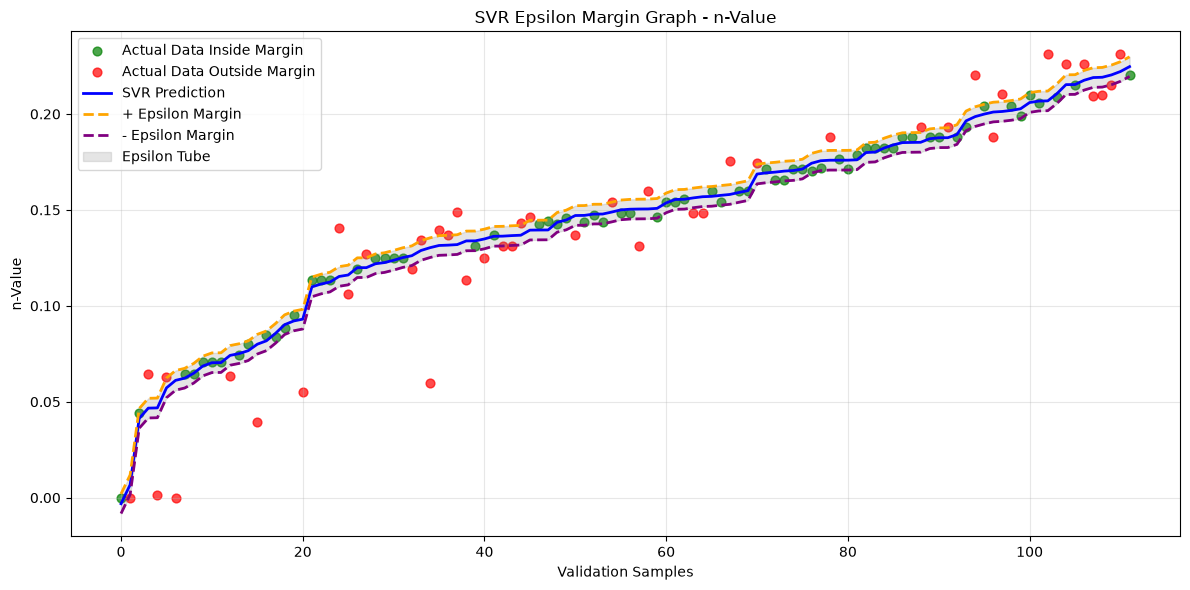


========== n-Value ==========
Total Actual Data Points : 112
Inside Margin (Green) : 68
Outside Margin (Red) : 44


In [14]:
sample_index = np.arange(
        len(actual_sorted)
    )
plt.figure(
        figsize=(12, 6)
    )


plt.scatter(
        sample_index[inside_margin],
        actual_sorted[inside_margin],
        color="green",
        label="Actual Data Inside Margin",
        alpha=0.7,
        s=40
    )


plt.scatter(
        sample_index[outside_margin],
        actual_sorted[outside_margin],
        color="red",
        label="Actual Data Outside Margin",
        alpha=0.7,
        s=40
    )

plt.plot(
        sample_index,
        predicted_sorted,
        color="blue",
        linewidth=2,
        label="SVR Prediction"
    )

plt.plot(
        sample_index,
        upper_margin,
        color="orange",
        linestyle="--",
        linewidth=2,
        label="+ Epsilon Margin"
    )

plt.plot(
        sample_index,
        lower_margin,
        color="purple",
        linestyle="--",
        linewidth=2,
        label="- Epsilon Margin"
    )

plt.fill_between(
        sample_index,
        lower_margin,
        upper_margin,
        color="gray",
        alpha=0.2,
        label="Epsilon Tube"
    )

plt.title(
        "SVR Epsilon Margin Graph - " + column
    )

plt.xlabel(
        "Validation Samples"
    )

plt.ylabel(
        column
    )

plt.legend()

plt.grid(
        True,
        alpha=0.3
    )

plt.tight_layout()

plt.show()

print(
        "\n==========",
        column,
        "=========="
    )


print(
        "Total Actual Data Points :",
        len(actual_sorted)
    )


print(
        "Inside Margin (Green) :",
        np.sum(inside_margin)
    )


print(
        "Outside Margin (Red) :",
        np.sum(outside_margin)
    )

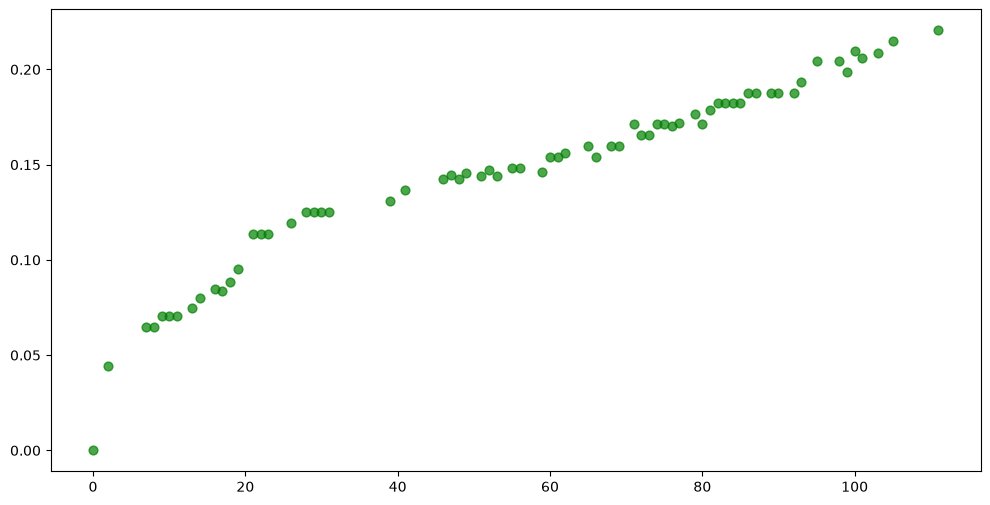

In [15]:
sample_index = np.arange(
        len(actual_sorted)
    )
plt.figure(
        figsize=(12, 6)
    )


plt.scatter(
        sample_index[inside_margin],
        actual_sorted[inside_margin],
        color="green",
        label="Actual Data Inside Margin",
        alpha=0.7,
        s=40
    )

In [16]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ============================================================
# TRAIN PREDICTION
# ============================================================

y_train_pred_scaled = model.predict(X_train_scaled)
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)

# ============================================================
# TEST PREDICTION
# ============================================================

y_test_pred_scaled = model.predict(X_validation_scaled)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)

# ============================================================
# OVERALL TRAIN METRICS
# ============================================================

train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# ============================================================
# OVERALL TEST METRICS
# ============================================================

test_r2 = r2_score(y_validation, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_validation, y_test_pred))

print("\n========== OVERALL RESULT ==========")
print(f"Train R2   : {train_r2:.4f}")
print(f"Train RMSE : {train_rmse:.4f}")
print()
print(f"Test R2    : {test_r2:.4f}")
print(f"Test RMSE  : {test_rmse:.4f}")


========== OVERALL RESULT ==========
Train R2   : 0.9950
Train RMSE : 3.7652

Test R2    : -7.2259
Test RMSE  : 14.7482
